# Monthly Sales Trends Analysis
This analysis aggregates sales by month, visualizes the trend, summarizes seasonality by calendar month, and flags unusual spikes or dips in monthly sales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

sales_df = pd.read_excel('sales.xlsx')
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')

# Use final paid amount as the revenue metric when available
sales_metric = 'FinalAmount' if 'FinalAmount' in sales_df.columns else 'TotalAmount'

analysis_df = sales_df[['Date', sales_metric]].dropna().copy()
analysis_df['year_month'] = analysis_df['Date'].dt.to_period('M').dt.to_timestamp()

monthly_sales = (
    analysis_df.groupby('year_month', as_index=False)[sales_metric]
    .sum()
    .rename(columns={'year_month': 'Month', sales_metric: 'MonthlySales'})
    .sort_values('Month')
)

monthly_sales['MonthLabel'] = monthly_sales['Month'].dt.strftime('%Y-%m')
monthly_sales['PctChange'] = monthly_sales['MonthlySales'].pct_change() * 100

# Robust anomaly score using median absolute deviation
median_sales = monthly_sales['MonthlySales'].median()
mad_sales = np.median(np.abs(monthly_sales['MonthlySales'] - median_sales))
if mad_sales == 0:
    monthly_sales['RobustZ'] = 0
else:
    monthly_sales['RobustZ'] = 0.6745 * (monthly_sales['MonthlySales'] - median_sales) / mad_sales

monthly_sales['AnomalyFlag'] = np.where(
    monthly_sales['RobustZ'] >= 2.5,
    'Unusual spike',
    np.where(monthly_sales['RobustZ'] <= -2.5, 'Unusual dip', 'Normal range')
)

monthly_sales['CalendarMonth'] = monthly_sales['Month'].dt.month_name()
calendar_order = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
seasonality_summary = (
    monthly_sales.groupby('CalendarMonth', as_index=False)['MonthlySales']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'AvgMonthlySales', 'median': 'MedianMonthlySales', 'count': 'ObservedMonths'})
)
seasonality_summary['CalendarMonth'] = pd.Categorical(
    seasonality_summary['CalendarMonth'], categories=calendar_order, ordered=True
)
seasonality_summary = seasonality_summary.sort_values('CalendarMonth')

print('Dataset date range:', analysis_df['Date'].min(), 'to', analysis_df['Date'].max())
print('Monthly periods analyzed:', len(monthly_sales))
print('\nMonthly sales table:')
print(monthly_sales[['MonthLabel', 'MonthlySales', 'PctChange', 'RobustZ', 'AnomalyFlag']].to_string(index=False))

print('\nSeasonality summary by calendar month:')
print(seasonality_summary.to_string(index=False))

Dataset date range: 2022-01-01 01:42:00 to 2023-12-10 20:16:00
Monthly periods analyzed: 24

Monthly sales table:
MonthLabel  MonthlySales  PctChange   RobustZ   AnomalyFlag
   2022-01     9193.0975        NaN -1.084389  Normal range
   2022-02     9945.2720   8.181948 -0.674549  Normal range
   2022-03     9945.4510   0.001800 -0.674451  Normal range
   2022-04    11720.4500  17.847345  0.292700  Normal range
   2022-05    15860.2285  35.320986  2.548360 Unusual spike
   2022-06     8652.7620 -45.443649 -1.378804  Normal range
   2022-07     8808.1375   1.795675 -1.294144  Normal range
   2022-08    11612.4715  31.837991  0.233866  Normal range
   2022-09    10800.6695  -6.990777 -0.208464  Normal range
   2022-10    11382.3725   5.385805  0.108491  Normal range
   2022-11    12485.3410   9.690146  0.709470  Normal range
   2022-12    15974.9180  27.949393  2.610852 Unusual spike
   2023-01    11601.5695 -27.376344  0.227925  Normal range
   2023-02    11465.3915  -1.173789  0.153726 

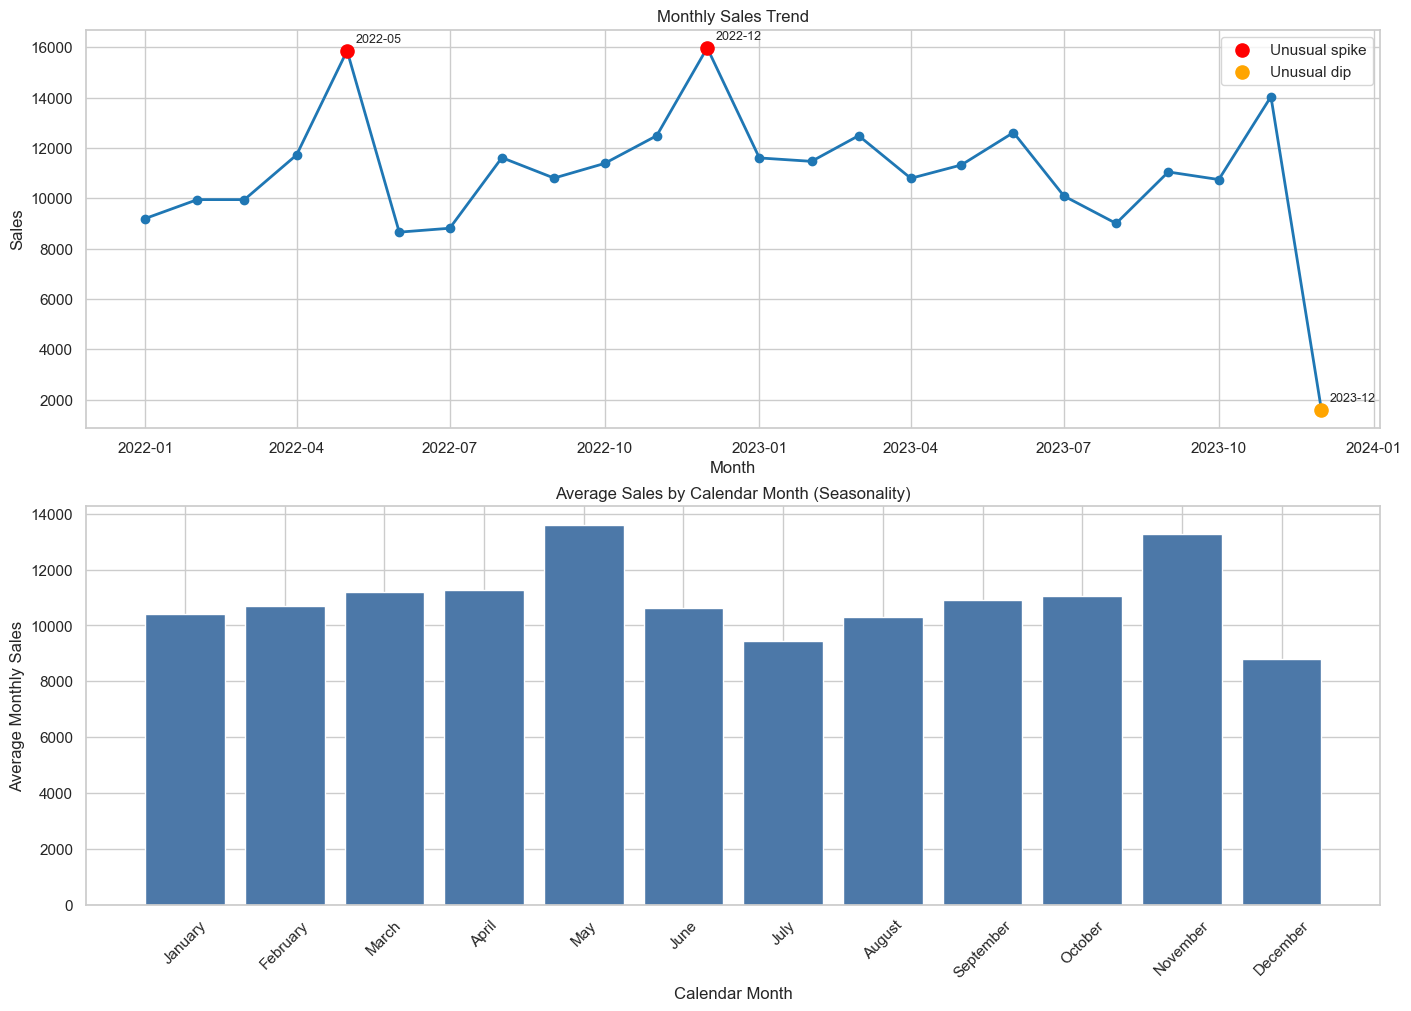

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

# Trend line with anomalies highlighted
axes[0].plot(monthly_sales['Month'], monthly_sales['MonthlySales'], marker='o', linewidth=2, color='#1f77b4')
spikes = monthly_sales[monthly_sales['AnomalyFlag'] == 'Unusual spike']
dips = monthly_sales[monthly_sales['AnomalyFlag'] == 'Unusual dip']
axes[0].scatter(spikes['Month'], spikes['MonthlySales'], color='red', s=90, label='Unusual spike', zorder=3)
axes[0].scatter(dips['Month'], dips['MonthlySales'], color='orange', s=90, label='Unusual dip', zorder=3)
for _, row in pd.concat([spikes, dips]).iterrows():
    axes[0].annotate(row['MonthLabel'], (row['Month'], row['MonthlySales']), xytext=(6, 6),
                     textcoords='offset points', fontsize=9)
axes[0].set_title('Monthly Sales Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sales')
axes[0].legend()

# Average sales by calendar month to show seasonality
seasonality_plot = seasonality_summary.dropna(subset=['AvgMonthlySales']).copy()
axes[1].bar(seasonality_plot['CalendarMonth'].astype(str), seasonality_plot['AvgMonthlySales'], color='#4c78a8')
axes[1].set_title('Average Sales by Calendar Month (Seasonality)')
axes[1].set_xlabel('Calendar Month')
axes[1].set_ylabel('Average Monthly Sales')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

In [3]:
top_spikes = monthly_sales[monthly_sales['AnomalyFlag'] != 'Normal range'].copy()
strongest_months = monthly_sales.nlargest(3, 'MonthlySales')[['MonthLabel', 'MonthlySales']]
weakest_months = monthly_sales.nsmallest(3, 'MonthlySales')[['MonthLabel', 'MonthlySales']]
peak_season = seasonality_summary.sort_values('AvgMonthlySales', ascending=False).head(3)[['CalendarMonth', 'AvgMonthlySales']]
slow_season = seasonality_summary.sort_values('AvgMonthlySales', ascending=True).head(3)[['CalendarMonth', 'AvgMonthlySales']]

print('Top 3 revenue months:')
print(strongest_months.to_string(index=False))
print('\nBottom 3 revenue months:')
print(weakest_months.to_string(index=False))
print('\nHighest average seasonal months:')
print(peak_season.to_string(index=False))
print('\nLowest average seasonal months:')
print(slow_season.to_string(index=False))
print('\nFlagged unusual months:')
print(top_spikes[['MonthLabel', 'MonthlySales', 'PctChange', 'RobustZ', 'AnomalyFlag']].to_string(index=False))

Top 3 revenue months:
MonthLabel  MonthlySales
   2022-12    15974.9180
   2022-05    15860.2285
   2023-11    14035.7435

Bottom 3 revenue months:
MonthLabel  MonthlySales
   2023-12     1587.5910
   2022-06     8652.7620
   2022-07     8808.1375

Highest average seasonal months:
CalendarMonth  AvgMonthlySales
          May      13590.83400
     November      13260.54225
        April      11255.99850

Lowest average seasonal months:
CalendarMonth  AvgMonthlySales
     December       8781.25450
         July       9447.98375
       August      10306.32775

Flagged unusual months:
MonthLabel  MonthlySales  PctChange   RobustZ   AnomalyFlag
   2022-05    15860.2285  35.320986  2.548360 Unusual spike
   2022-12    15974.9180  27.949393  2.610852 Unusual spike
   2023-12     1587.5910 -88.688943 -5.228436   Unusual dip


# Geographic and Product Trend Analysis
This section analyzes monthly sales trends by **Region** and **Product category**, identifies seasonality within each segment, and flags unusual spikes or dips for region-product combinations.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales_df = pd.read_excel('sales.xlsx')
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')

sales_metric = 'FinalAmount' if 'FinalAmount' in sales_df.columns else 'TotalAmount'
analysis_df = sales_df[['Date', 'Region', 'City', 'Product', sales_metric]].dropna(subset=['Date', 'Region', 'Product', sales_metric]).copy()

# Standardize product names so capitalization variants collapse to one category
analysis_df['ProductCategory'] = analysis_df['Product'].astype(str).str.strip().str.title()
analysis_df['Month'] = analysis_df['Date'].dt.to_period('M').dt.to_timestamp()
analysis_df['CalendarMonth'] = analysis_df['Date'].dt.month_name()

region_monthly = (
    analysis_df.groupby(['Month', 'Region'], as_index=False)[sales_metric]
    .sum()
    .rename(columns={sales_metric: 'MonthlySales'})
)

product_monthly = (
    analysis_df.groupby(['Month', 'ProductCategory'], as_index=False)[sales_metric]
    .sum()
    .rename(columns={sales_metric: 'MonthlySales'})
)

region_product_monthly = (
    analysis_df.groupby(['Month', 'Region', 'ProductCategory'], as_index=False)[sales_metric]
    .sum()
    .rename(columns={sales_metric: 'MonthlySales'})
)

# Rank leading regions and products overall
region_totals = region_monthly.groupby('Region', as_index=False)['MonthlySales'].sum().sort_values('MonthlySales', ascending=False)
product_totals = product_monthly.groupby('ProductCategory', as_index=False)['MonthlySales'].sum().sort_values('MonthlySales', ascending=False)
region_product_totals = region_product_monthly.groupby(['Region', 'ProductCategory'], as_index=False)['MonthlySales'].sum().sort_values('MonthlySales', ascending=False)

# Seasonality by region and product
calendar_order = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']

region_seasonality = (
    region_monthly.assign(CalendarMonth=region_monthly['Month'].dt.month_name())
    .groupby(['Region', 'CalendarMonth'], as_index=False)['MonthlySales']
    .mean()
    .rename(columns={'MonthlySales': 'AvgMonthlySales'})
)
region_seasonality['CalendarMonth'] = pd.Categorical(region_seasonality['CalendarMonth'], categories=calendar_order, ordered=True)
region_seasonality = region_seasonality.sort_values(['Region', 'CalendarMonth'])

product_seasonality = (
    product_monthly.assign(CalendarMonth=product_monthly['Month'].dt.month_name())
    .groupby(['ProductCategory', 'CalendarMonth'], as_index=False)['MonthlySales']
    .mean()
    .rename(columns={'MonthlySales': 'AvgMonthlySales'})
)
product_seasonality['CalendarMonth'] = pd.Categorical(product_seasonality['CalendarMonth'], categories=calendar_order, ordered=True)
product_seasonality = product_seasonality.sort_values(['ProductCategory', 'CalendarMonth'])

# Robust anomaly scoring within each region-product time series
region_product_monthly = region_product_monthly.sort_values(['Region', 'ProductCategory', 'Month']).copy()

def add_segment_anomaly_flags(segment_df):
    segment_df = segment_df.copy()
    median_value = segment_df['MonthlySales'].median()
    mad_value = np.median(np.abs(segment_df['MonthlySales'] - median_value))
    if mad_value == 0:
        segment_df['RobustZ'] = 0.0
    else:
        segment_df['RobustZ'] = 0.6745 * (segment_df['MonthlySales'] - median_value) / mad_value
    segment_df['AnomalyFlag'] = np.where(
        segment_df['RobustZ'] >= 2.5,
        'Unusual spike',
        np.where(segment_df['RobustZ'] <= -2.5, 'Unusual dip', 'Normal range')
    )
    return segment_df

region_product_anomalies = pd.concat(
    [add_segment_anomaly_flags(group) for _, group in region_product_monthly.groupby(['Region', 'ProductCategory'])],
    ignore_index=True
)

flagged_region_product_months = region_product_anomalies[
    region_product_anomalies['AnomalyFlag'] != 'Normal range'
].copy()
flagged_region_product_months['MonthLabel'] = flagged_region_product_months['Month'].dt.strftime('%Y-%m')

print('Overall sales by region:')
print(region_totals.to_string(index=False))
print('\nOverall sales by product category:')
print(product_totals.to_string(index=False))
print('\nTop 10 region-product combinations by total sales:')
print(region_product_totals.head(10).to_string(index=False))
print('\nFlagged unusual region-product months:')
if flagged_region_product_months.empty:
    print('No unusual region-product months were flagged at the current threshold.')
else:
    print(flagged_region_product_months[['MonthLabel', 'Region', 'ProductCategory', 'MonthlySales', 'RobustZ', 'AnomalyFlag']].sort_values(['Region', 'ProductCategory', 'MonthLabel']).to_string(index=False))

Overall sales by region:
   Region  MonthlySales
     West    108928.315
    South     69986.154
Northeast     52871.019
  Midwest     31371.344

Overall sales by product category:
ProductCategory  MonthlySales
         Jacket    70327.2640
       Sneakers    49569.5755
          Dress    38931.2670
        Sweater    33525.2105
          Jeans    29835.4750
          Skirt    22776.5810
        T-Shirt    12718.5640
          Socks     5472.8950

Top 10 region-product combinations by total sales:
   Region ProductCategory  MonthlySales
     West          Jacket    25271.1810
     West        Sneakers    21525.9375
    South          Jacket    18535.1425
     West         Sweater    16997.7740
     West           Dress    16757.2880
Northeast          Jacket    16643.9240
    South        Sneakers    12319.9500
     West           Jeans    11698.4935
    South           Dress    11397.8015
    South           Jeans     9879.9835

Flagged unusual region-product months:
MonthLabel    Reg

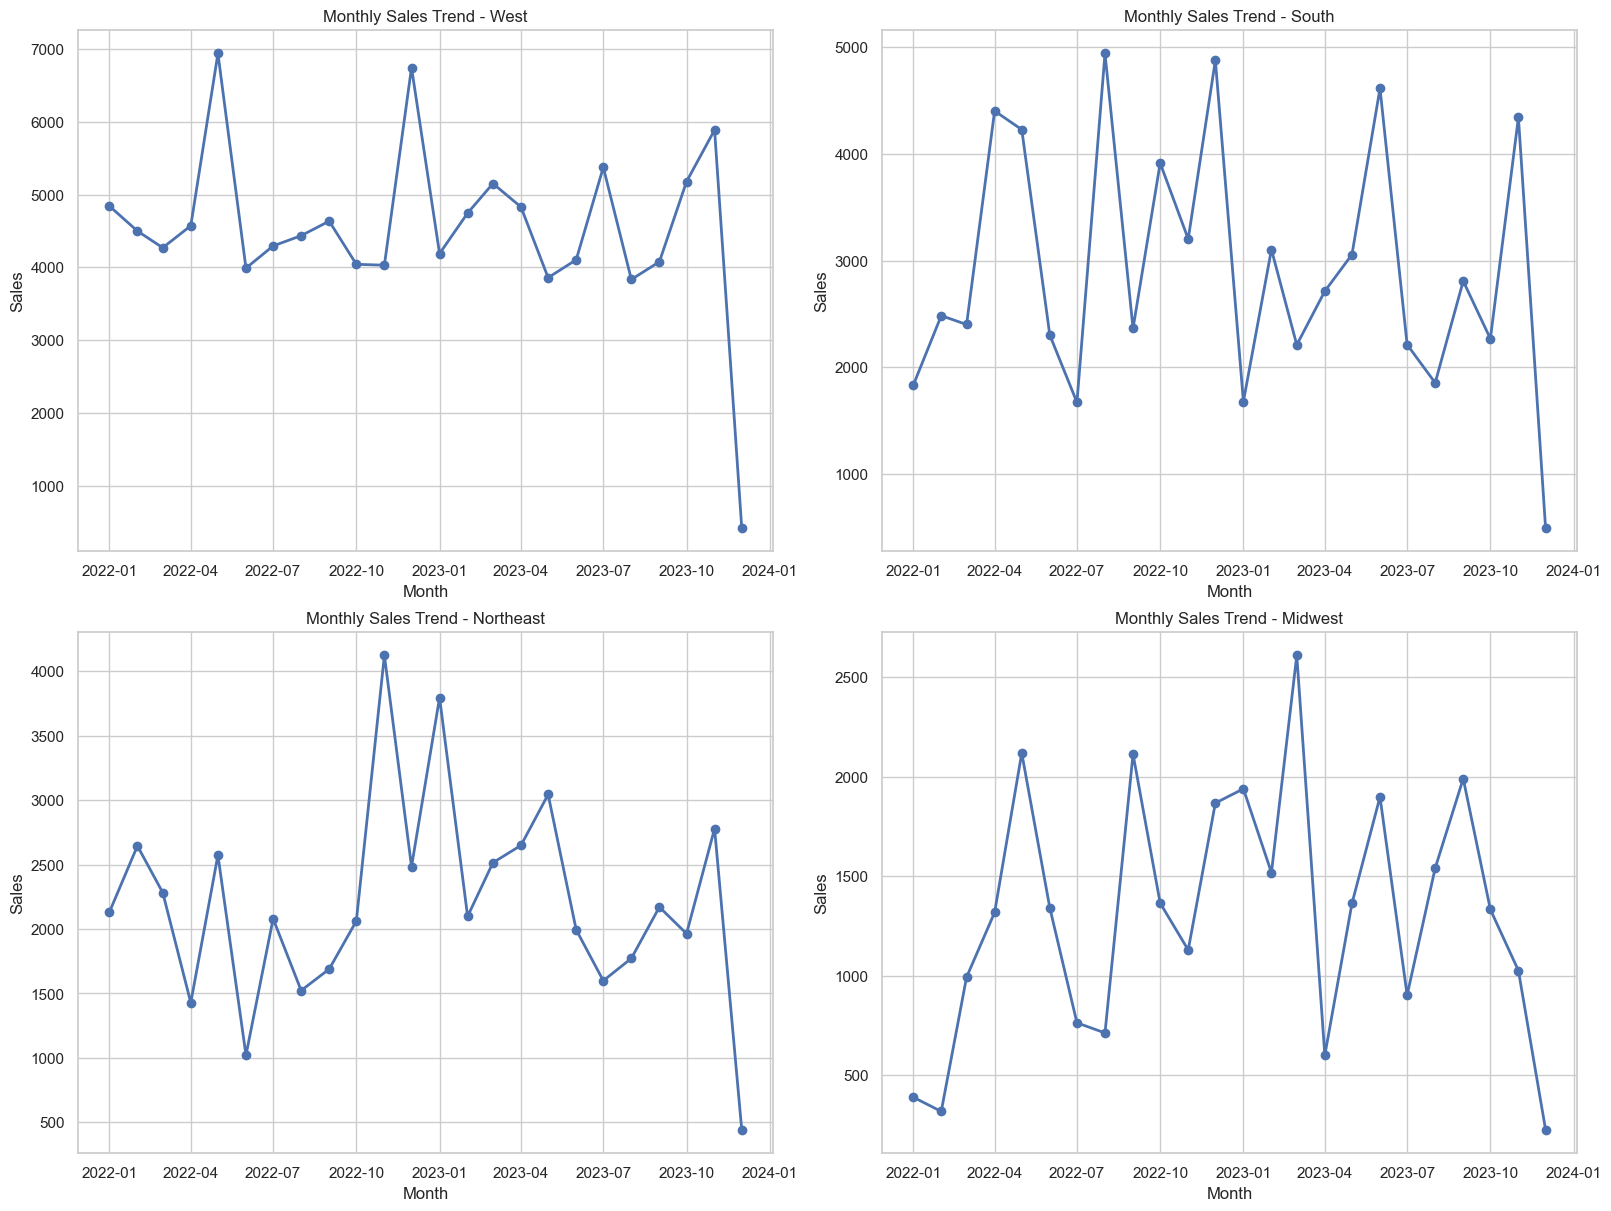

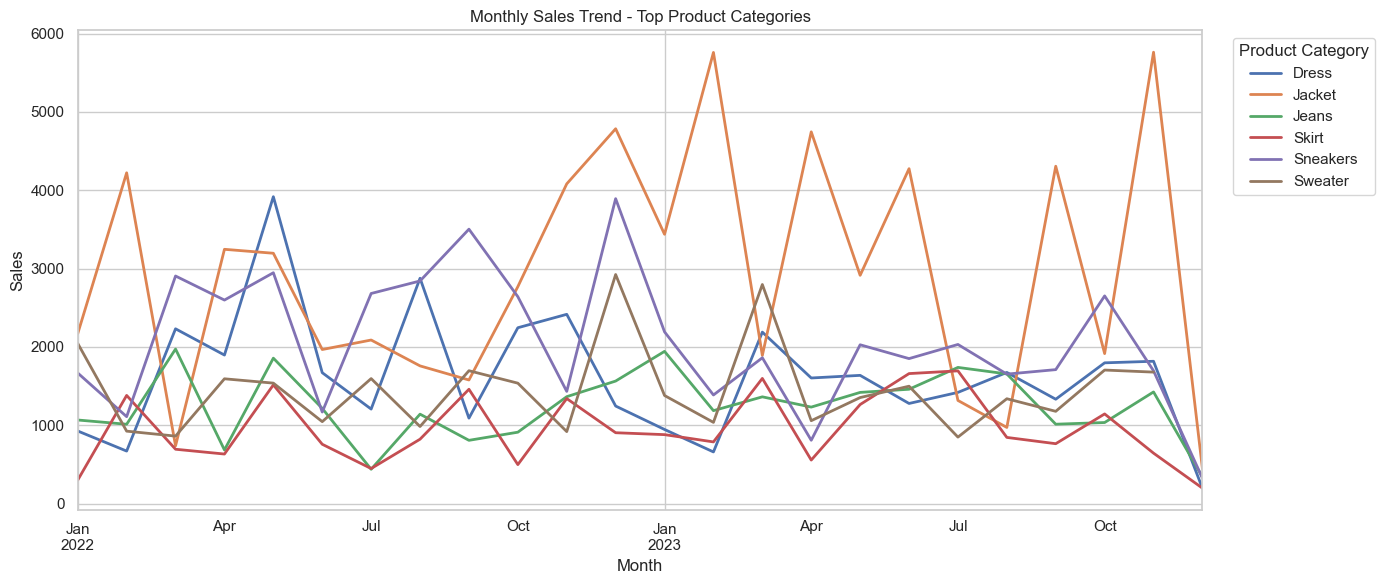

In [5]:
top_regions = region_totals.head(4)['Region'].tolist()
top_products = product_totals.head(6)['ProductCategory'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
axes = axes.flatten()

for i, region in enumerate(top_regions):
    region_series = region_monthly[region_monthly['Region'] == region].sort_values('Month')
    axes[i].plot(region_series['Month'], region_series['MonthlySales'], marker='o', linewidth=2)
    axes[i].set_title(f'Monthly Sales Trend - {region}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Sales')

plt.show()

plt.figure(figsize=(14, 6))
product_pivot = product_monthly[product_monthly['ProductCategory'].isin(top_products)].pivot(index='Month', columns='ProductCategory', values='MonthlySales')
product_pivot.plot(ax=plt.gca(), linewidth=2)
plt.title('Monthly Sales Trend - Top Product Categories')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

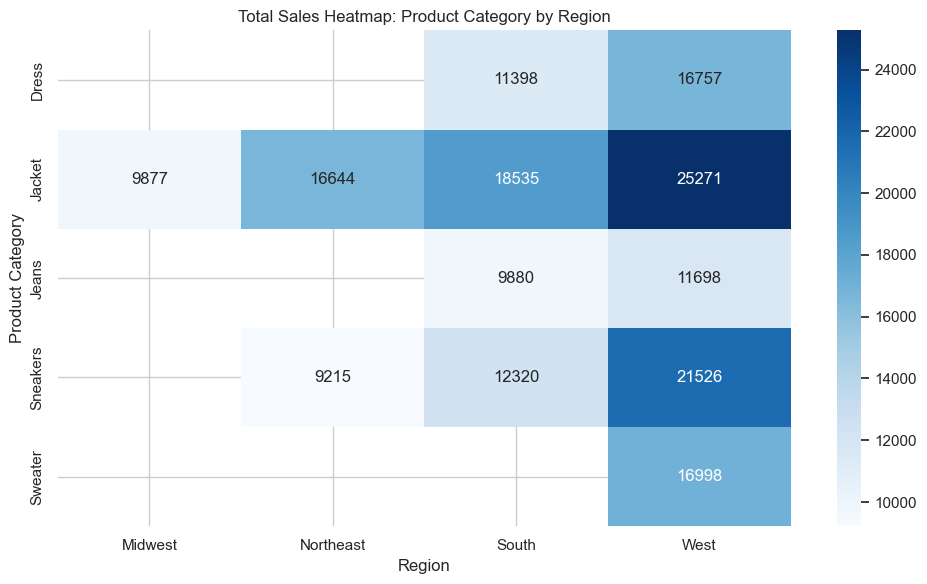

Top seasonal months by region:
   Region CalendarMonth  AvgMonthlySales
  Midwest     September       2051.51250
  Midwest         March       1801.04875
  Midwest           May       1740.77350
Northeast      November       3451.92175
Northeast       January       2963.18750
Northeast           May       2808.94125
    South      November       3772.95325
    South           May       3642.80275
    South         April       3558.62200
     West           May       5398.31650
     West      November       4958.35625
     West          July       4833.80500

Top seasonal months by product category:
ProductCategory CalendarMonth  AvgMonthlySales
          Dress           May       2776.71100
          Dress        August       2275.09300
          Dress         March       2209.63900
         Jacket      February       4990.45800
         Jacket      November       4921.45000
         Jacket         April       3995.27900
          Jeans         March       1667.40875
          Jeans   

In [6]:
top_region_product = region_product_totals.head(12).copy()
heatmap_df = top_region_product.pivot(index='ProductCategory', columns='Region', values='MonthlySales')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='Blues')
plt.title('Total Sales Heatmap: Product Category by Region')
plt.xlabel('Region')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

region_peak_months = (
    region_seasonality.sort_values(['Region', 'AvgMonthlySales'], ascending=[True, False])
    .groupby('Region')
    .head(3)
)
product_peak_months = (
    product_seasonality.sort_values(['ProductCategory', 'AvgMonthlySales'], ascending=[True, False])
    .groupby('ProductCategory')
    .head(3)
)

print('Top seasonal months by region:')
print(region_peak_months.to_string(index=False))
print('\nTop seasonal months by product category:')
print(product_peak_months.to_string(index=False))